### IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import skimage.io
import os 
import tqdm
import glob
import tensorflow 

from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from skimage.io import imread, imshow
from skimage.transform import resize
#from skimage.color import grey2rgb

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.utils import to_categorical
from keras import optimizers

from keras.callbacks import Callback,ModelCheckpoint
from keras.models import Sequential,load_model
from keras.layers import Dense, Dropout
from keras.wrappers.scikit_learn import KerasClassifier
import keras.backend as K

#import tensorflow_addons as tfa
#from tensorflow.keras.metrics import Metric
#from tensorflow_addons.utils.types import AcceptableDTypes, FloatTensorLike
from typeguard import typechecked
from typing import Optional
import tensorflow 

from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

from skimage.io import imread, imshow
from skimage.transform import resize
#from skimage.color import grey2rgb

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.densenet import DenseNet169
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import keras.backend as K

2025-03-16 22:09:39.709257: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-16 22:09:39.886571: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-16 22:09:41.249405: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64:/usr/lib/x86_64-linux-gnu/:/opt/conda/lib
2025-03-16 22:09:41.249537: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] 

In [9]:
# split localisation data

import os
import shutil
from sklearn.model_selection import train_test_split

# Define paths
data_dir = "../localisation_outputs/"  # Replace with your dataset folder path
output_dir = "../localisation_split"
train_dir = os.path.join(output_dir, "train")
test_dir = os.path.join(output_dir, "test")

# Ensure train & test directories exist
for split in [train_dir, test_dir]:
    for category in ["AD", "MCI", "CN"]:
        os.makedirs(os.path.join(split, category), exist_ok=True)

# Split and move files
for category in ["AD", "MCI", "CN"]:
    category_path = os.path.join(data_dir, category)
    for folder in os.listdir(category_path):
        folder_path = os.path.join(category_path, folder)
        if os.path.isdir(folder_path):
            for image in os.listdir(folder_path):
                if image.endswith(".png"):
                    split = np.random.rand()  # Generate random number for splitting

                    if split <= 0.80:  # 80% to train
                        shutil.move(os.path.join(folder_path, image), os.path.join(train_dir, category, image))
                    else:  # 20% to test
                        shutil.move(os.path.join(folder_path, image), os.path.join(test_dir, category, image))

print("Dataset split completed successfully!")


Dataset split completed successfully!


In [10]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

In [11]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   validation_split = 0.2,
                                  
        rotation_range=5,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        #zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

valid_datagen = ImageDataGenerator(rescale = 1./255,
                                  validation_split = 0.2)

test_datagen  = ImageDataGenerator(rescale = 1./255
                                  )

In [12]:
#train_dataset = tf.keras.preprocessing.image_dataset_from_directory('../input/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train',
#                                                                        validation_split=0.2,
#                                                                        subset="training",
#                                                                        shuffle=False,
#                                                                        image_size=(224,224),
#                                                                        batch_size=32,
#                                                                        )

train_dataset  = train_datagen.flow_from_directory(directory = '../localisation_split/train',
                                                   target_size = (224,224),
                                                   class_mode = 'categorical',
                                                   subset = 'training',
                                                   batch_size = 128)

Found 5437 images belonging to 3 classes.


In [13]:
#valid_dataset = tf.keras.preprocessing.image_dataset_from_directory('../input/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train',
#                                                                        validation_split=0.2,
#                                                                        subset="validation",
#                                                                        shuffle=False,
#                                                                        image_size=(224,224),
#                                                                        batch_size=32,
#                                                                        )
valid_dataset = valid_datagen.flow_from_directory(directory = '../localisation_split/train',
                                                  target_size = (224,224),
                                                  class_mode = 'categorical',
                                                  subset = 'validation',
                                                  batch_size = 128)

Found 1359 images belonging to 3 classes.


## feature preprocessing and label encoding.

### MODEL BUILDING

In [14]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(224,224,3), 
                   include_top=False,
                   weights="imagenet")

2025-03-16 22:36:13.487755: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-16 22:36:13.518004: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-16 22:36:13.518838: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-03-16 22:36:13.519965: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

In [15]:
# Freezing Layers

for layer in base_model.layers:
    layer.trainable=False

In [16]:
# Building Model

model=Sequential()
model.add(base_model)
model.add(Dropout(0.5))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(3,activation='softmax'))

In [17]:
# Model Summary

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 dropout (Dropout)           (None, 7, 7, 1280)        0         
                                                                 
 flatten (Flatten)           (None, 62720)             0         
                                                                 
 batch_normalization (BatchN  (None, 62720)            250880    
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 32)                2007072   
                                                                 
 batch_normalization_1 (Batc  (None, 32)               1

In [18]:
def f1_score(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [19]:
OPT    = tensorflow.keras.optimizers.Adam(lr=0.001)
METRICS = [
      tensorflow.keras.metrics.AUC(name = 'auc'),
      tensorflow.keras.metrics.CategoricalAccuracy(name='accuracy'),
      tensorflow.keras.metrics.Precision(name='precision'),
      tensorflow.keras.metrics.Recall(name='recall'),  
        f1_score,
          ]
model.compile(loss='categorical_crossentropy',
              metrics=METRICS,
              optimizer=OPT)

/opt/conda/lib/python3.10/site-packages/keras/optimizers/optimizer_v2/adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [20]:
# Defining Callbacks
filepath = '../models/saved/best_weights_mos.hdf5'

earlystopping = EarlyStopping(monitor = 'val_auc', 
                              mode = 'max' , 
                              patience = 15,
                              verbose = 1)

checkpoint    = ModelCheckpoint(filepath, 
                                monitor = 'val_auc', 
                                mode='max', 
                                save_best_only=True, 
                                verbose = 1)


callback_list = [earlystopping, checkpoint]

In [21]:
model_history=model.fit(train_dataset,
                        validation_data=valid_dataset,
                        epochs = 100,
                        callbacks = callback_list,
                        verbose = 1)

Epoch 1/100


2025-03-16 22:36:29.113961: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8900


43/43 [==============================] - ETA: 0s - loss: 1.4129 - auc: 0.4629 - accuracy: 0.2851 - precision: 0.2709 - recall: 0.1527 - f1_score: 0.1946
Epoch 1: val_auc improved from -inf to 0.66612, saving model to ../models/saved/best_weights_mos.hdf5
43/43 [==============================] - 76s 2s/step - loss: 1.4129 - auc: 0.4629 - accuracy: 0.2851 - precision: 0.2709 - recall: 0.1527 - f1_score: 0.1946 - val_loss: 1.1437 - val_auc: 0.6661 - val_accuracy: 0.5004 - val_precision: 0.5586 - val_recall: 0.4172 - val_f1_score: 0.4784
Epoch 2/100
43/43 [==============================] - ETA: 0s - loss: 1.1376 - auc: 0.5785 - accuracy: 0.4074 - precision: 0.4533 - recall: 0.1705 - f1_score: 0.2487
Epoch 2: val_auc improved from 0.66612 to 0.70184, saving model to ../models/saved/best_weights_mos.hdf5
43/43 [==============================] - 62s 1s/step - loss: 1.1376 - auc: 0.5785 - accuracy: 0.4074 - precision: 0.4533 - recall: 0.1705 - f1_score: 0.2487 - val_loss: 0.9987 - val_auc: 0.7

43/43 [==============================] - ETA: 0s - loss: 0.9056 - auc: 0.7555 - accuracy: 0.5534 - precision: 0.6317 - recall: 0.3873 - f1_score: 0.4793
Epoch 16: val_auc did not improve from 0.82486
43/43 [==============================] - 61s 1s/step - loss: 0.9056 - auc: 0.7555 - accuracy: 0.5534 - precision: 0.6317 - recall: 0.3873 - f1_score: 0.4793 - val_loss: 0.8119 - val_auc: 0.8245 - val_accuracy: 0.6630 - val_precision: 0.7352 - val_recall: 0.5475 - val_f1_score: 0.6267
Epoch 17/100
43/43 [==============================] - ETA: 0s - loss: 0.8957 - auc: 0.7622 - accuracy: 0.5632 - precision: 0.6246 - recall: 0.3956 - f1_score: 0.4843
Epoch 17: val_auc did not improve from 0.82486
43/43 [==============================] - 61s 1s/step - loss: 0.8957 - auc: 0.7622 - accuracy: 0.5632 - precision: 0.6246 - recall: 0.3956 - f1_score: 0.4843 - val_loss: 0.8396 - val_auc: 0.8133 - val_accuracy: 0.6439 - val_precision: 0.7240 - val_recall: 0.5269 - val_f1_score: 0.6098
Epoch 18/100
43/4

Epoch 32/100
43/43 [==============================] - ETA: 0s - loss: 0.7960 - auc: 0.8222 - accuracy: 0.6401 - precision: 0.6994 - recall: 0.5417 - f1_score: 0.6107
Epoch 32: val_auc did not improve from 0.87425
43/43 [==============================] - 62s 1s/step - loss: 0.7960 - auc: 0.8222 - accuracy: 0.6401 - precision: 0.6994 - recall: 0.5417 - f1_score: 0.6107 - val_loss: 0.7127 - val_auc: 0.8687 - val_accuracy: 0.7270 - val_precision: 0.7667 - val_recall: 0.6600 - val_f1_score: 0.7092
Epoch 33/100
43/43 [==============================] - ETA: 0s - loss: 0.7920 - auc: 0.8211 - accuracy: 0.6402 - precision: 0.6892 - recall: 0.5396 - f1_score: 0.6051
Epoch 33: val_auc improved from 0.87425 to 0.87565, saving model to ../models/saved/best_weights_mos.hdf5
43/43 [==============================] - 62s 1s/step - loss: 0.7920 - auc: 0.8211 - accuracy: 0.6402 - precision: 0.6892 - recall: 0.5396 - f1_score: 0.6051 - val_loss: 0.7025 - val_auc: 0.8757 - val_accuracy: 0.7432 - val_precisi

Epoch 48/100
43/43 [==============================] - ETA: 0s - loss: 0.7460 - auc: 0.8451 - accuracy: 0.6706 - precision: 0.7149 - recall: 0.6011 - f1_score: 0.6527
Epoch 48: val_auc improved from 0.89567 to 0.89967, saving model to ../models/saved/best_weights_mos.hdf5
43/43 [==============================] - 63s 1s/step - loss: 0.7460 - auc: 0.8451 - accuracy: 0.6706 - precision: 0.7149 - recall: 0.6011 - f1_score: 0.6527 - val_loss: 0.6316 - val_auc: 0.8997 - val_accuracy: 0.7704 - val_precision: 0.8083 - val_recall: 0.7138 - val_f1_score: 0.7567
Epoch 49/100
43/43 [==============================] - ETA: 0s - loss: 0.7215 - auc: 0.8562 - accuracy: 0.6842 - precision: 0.7287 - recall: 0.6160 - f1_score: 0.6680
Epoch 49: val_auc did not improve from 0.89967
43/43 [==============================] - 63s 1s/step - loss: 0.7215 - auc: 0.8562 - accuracy: 0.6842 - precision: 0.7287 - recall: 0.6160 - f1_score: 0.6680 - val_loss: 0.6499 - val_auc: 0.8910 - val_accuracy: 0.7542 - val_precisi

43/43 [==============================] - ETA: 0s - loss: 0.6809 - auc: 0.8735 - accuracy: 0.7155 - precision: 0.7476 - recall: 0.6601 - f1_score: 0.7011
Epoch 64: val_auc did not improve from 0.91648
43/43 [==============================] - 64s 1s/step - loss: 0.6809 - auc: 0.8735 - accuracy: 0.7155 - precision: 0.7476 - recall: 0.6601 - f1_score: 0.7011 - val_loss: 0.6040 - val_auc: 0.9056 - val_accuracy: 0.7748 - val_precision: 0.8045 - val_recall: 0.7358 - val_f1_score: 0.7674
Epoch 65/100
43/43 [==============================] - ETA: 0s - loss: 0.6699 - auc: 0.8772 - accuracy: 0.7129 - precision: 0.7508 - recall: 0.6616 - f1_score: 0.7032
Epoch 65: val_auc did not improve from 0.91648
43/43 [==============================] - 64s 1s/step - loss: 0.6699 - auc: 0.8772 - accuracy: 0.7129 - precision: 0.7508 - recall: 0.6616 - f1_score: 0.7032 - val_loss: 0.5801 - val_auc: 0.9159 - val_accuracy: 0.7859 - val_precision: 0.8211 - val_recall: 0.7461 - val_f1_score: 0.7804
Epoch 66/100
43/4

43/43 [==============================] - ETA: 0s - loss: 0.6336 - auc: 0.8898 - accuracy: 0.7291 - precision: 0.7592 - recall: 0.6825 - f1_score: 0.7195
Epoch 80: val_auc did not improve from 0.92027
43/43 [==============================] - 61s 1s/step - loss: 0.6336 - auc: 0.8898 - accuracy: 0.7291 - precision: 0.7592 - recall: 0.6825 - f1_score: 0.7195 - val_loss: 0.5735 - val_auc: 0.9147 - val_accuracy: 0.7925 - val_precision: 0.8163 - val_recall: 0.7586 - val_f1_score: 0.7844
Epoch 81/100
43/43 [==============================] - ETA: 0s - loss: 0.6294 - auc: 0.8919 - accuracy: 0.7370 - precision: 0.7659 - recall: 0.6903 - f1_score: 0.7255
Epoch 81: val_auc did not improve from 0.92027
43/43 [==============================] - 61s 1s/step - loss: 0.6294 - auc: 0.8919 - accuracy: 0.7370 - precision: 0.7659 - recall: 0.6903 - f1_score: 0.7255 - val_loss: 0.5829 - val_auc: 0.9128 - val_accuracy: 0.7991 - val_precision: 0.8238 - val_recall: 0.7638 - val_f1_score: 0.7916
Epoch 82/100
43/4

43/43 [==============================] - 60s 1s/step - loss: 0.5981 - auc: 0.9023 - accuracy: 0.7469 - precision: 0.7723 - recall: 0.7155 - f1_score: 0.7434 - val_loss: 0.5749 - val_auc: 0.9133 - val_accuracy: 0.7896 - val_precision: 0.8134 - val_recall: 0.7601 - val_f1_score: 0.7842
Epoch 97/100
43/43 [==============================] - ETA: 0s - loss: 0.6063 - auc: 0.8995 - accuracy: 0.7418 - precision: 0.7729 - recall: 0.7098 - f1_score: 0.7395
Epoch 97: val_auc did not improve from 0.92689
43/43 [==============================] - 61s 1s/step - loss: 0.6063 - auc: 0.8995 - accuracy: 0.7418 - precision: 0.7729 - recall: 0.7098 - f1_score: 0.7395 - val_loss: 0.5682 - val_auc: 0.9148 - val_accuracy: 0.8006 - val_precision: 0.8128 - val_recall: 0.7638 - val_f1_score: 0.7865
Epoch 98/100
43/43 [==============================] - ETA: 0s - loss: 0.5923 - auc: 0.9049 - accuracy: 0.7530 - precision: 0.7846 - recall: 0.7142 - f1_score: 0.7485
Epoch 98: val_auc did not improve from 0.92689
43/4

In [22]:
from tensorflow.keras.utils import to_categorical, plot_model
#plot_model(model, to_file='NN-mnist.png', show_shapes=True)

In [23]:
#model.load_weights("/kaggle/input/zahaimar-22/zahaimar_v2.h5")

In [24]:
#model.compile(optimizer='rmsprop', loss='categorical_crossentropy',metrics=METRICS)

In [25]:
#test_dataset = tf.keras.preprocessing.image_dataset_from_directory("../input/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test",
##                                                            shuffle=False,
#                                                            image_size=(224,224),
#                                                            batch_size=32,
#)

test_dataset = test_datagen.flow_from_directory(directory = '../localisation_split/test',
                                                  target_size = (224,224),
                                                  class_mode = 'categorical'
                                                  )

Found 1604 images belonging to 3 classes.


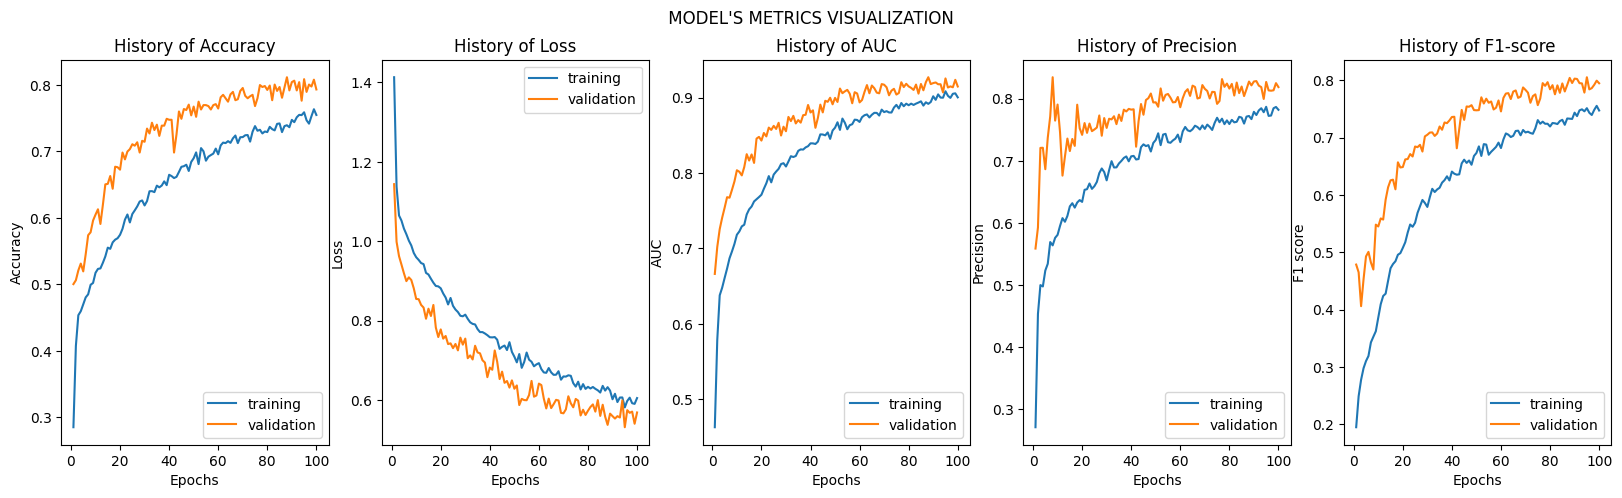

In [26]:
#%% PLOTTING RESULTS (Train vs Validation FOLDER 1)

def Train_Val_Plot(acc,val_acc,loss,val_loss,auc,val_auc,precision,val_precision,f1,val_f1):
    
    fig, (ax1, ax2,ax3,ax4,ax5) = plt.subplots(1,5, figsize= (20,5))
    fig.suptitle(" MODEL'S METRICS VISUALIZATION ")

    ax1.plot(range(1, len(acc) + 1), acc)
    ax1.plot(range(1, len(val_acc) + 1), val_acc)
    ax1.set_title('History of Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['training', 'validation'])


    ax2.plot(range(1, len(loss) + 1), loss)
    ax2.plot(range(1, len(val_loss) + 1), val_loss)
    ax2.set_title('History of Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(['training', 'validation'])
    
    ax3.plot(range(1, len(auc) + 1), auc)
    ax3.plot(range(1, len(val_auc) + 1), val_auc)
    ax3.set_title('History of AUC')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.legend(['training', 'validation'])
    
    ax4.plot(range(1, len(precision) + 1), precision)
    ax4.plot(range(1, len(val_precision) + 1), val_precision)
    ax4.set_title('History of Precision')
    ax4.set_xlabel('Epochs')
    ax4.set_ylabel('Precision')
    ax4.legend(['training', 'validation'])
    
    ax5.plot(range(1, len(f1) + 1), f1)
    ax5.plot(range(1, len(val_f1) + 1), val_f1)
    ax5.set_title('History of F1-score')
    ax5.set_xlabel('Epochs')
    ax5.set_ylabel('F1 score')
    ax5.legend(['training', 'validation'])


    plt.show()
    

Train_Val_Plot(model_history.history['accuracy'],model_history.history['val_accuracy'],
               model_history.history['loss'],model_history.history['val_loss'],
               model_history.history['auc'],model_history.history['val_auc'],
               model_history.history['precision'],model_history.history['val_precision'],
               model_history.history['f1_score'],model_history.history['val_f1_score']
              )

In [27]:
scores = model.evaluate(test_dataset)

51/51 [==============================] - 5s 81ms/step - loss: 0.5024 - auc: 0.9342 - accuracy: 0.8086 - precision: 0.8336 - recall: 0.7930 - f1_score: 0.8159


In [28]:
print("Accuracy = ", scores[1])
print("Precision = ", scores[2])
print("Recall = ", scores[3])
print("AUC = ", scores[4])
print("F1_score = ", scores[5])

Accuracy =  0.9342427253723145
Precision =  0.8086034655570984
Recall =  0.8335517644882202
AUC =  0.7930174469947815
F1_score =  0.8158895969390869


# Test on the DataSet

1/1 [==============================] - 0s 23ms/step
70.88 % chances are there that the image is [0]


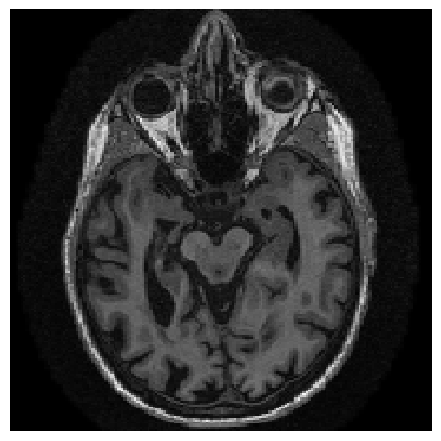

In [29]:
# Test Case 1: Alzheimers

dic = test_dataset.class_indices
idc = {k:v for v, k in dic.items()}

img = load_img('../localisation_split/test/AD/I97069_slice_8.png', target_size = (224,224,3))
img = img_to_array(img)
img = img/255
imshow(img)
plt.axis('off')
img = np.expand_dims(img,axis=0)

classes = np.argmax(model.predict(img),axis=1)

probability = round(np.max(model.predict(img)*100),2)


print(probability, '% chances are there that the image is', classes)

1/1 [==============================] - 0s 23ms/step
49.16 % chances are there that the image is [1]


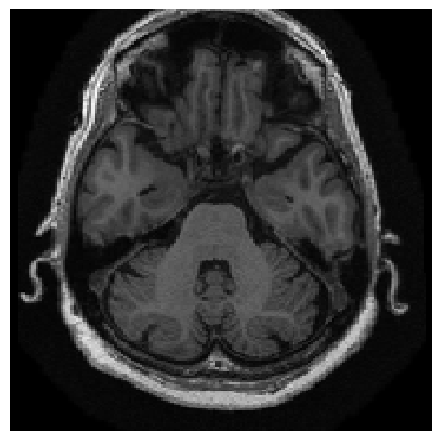

In [32]:
# Test Case 2: Cognitive Normal

dic = test_dataset.class_indices
idc = {k:v for v, k in dic.items()}

img = load_img('../localisation_split/test/CN/I99260_slice_16.png', target_size = (224,224,3))
img = img_to_array(img)
img = img/255
imshow(img)
plt.axis('off')
img = np.expand_dims(img,axis=0)

classes = np.argmax(model.predict(img),axis=1)

probability = round(np.max(model.predict(img)*100),2)


print(probability, '% chances are there that the image is', classes)

1/1 [==============================] - 0s 23ms/step
72.36 % chances are there that the image is [2]


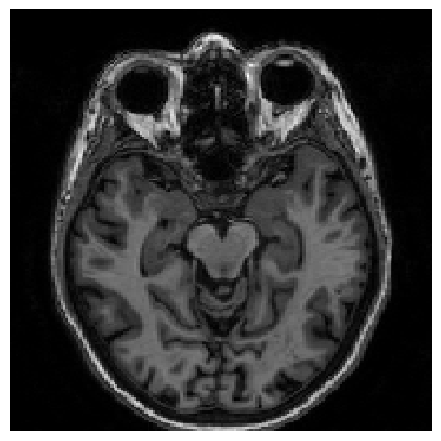

In [33]:
# Test Case 3: Mild Cognitive Impairment

dic = test_dataset.class_indices
idc = {k:v for v, k in dic.items()}

img = load_img('../localisation_split/test/MCI/I99265_slice_10.png', target_size = (224,224,3))
img = img_to_array(img)
img = img/255
imshow(img)
plt.axis('off')
img = np.expand_dims(img,axis=0)

classes = np.argmax(model.predict(img),axis=1)

probability = round(np.max(model.predict(img)*100),2)


print(probability, '% chances are there that the image is', classes)

# Confusion Matrix

In [36]:
model.save('models/mobilenet_localised.h5')



In [37]:
true_classes = test_dataset.classes
class_indices = test_dataset.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

preds = model.predict(test_dataset)
pred_classes = np.argmax(preds, axis=1)

51/51 [==============================] - 4s 70ms/step


In [38]:
print(train_dataset.class_indices.keys())

dict_keys(['AD', 'CN', 'MCI'])


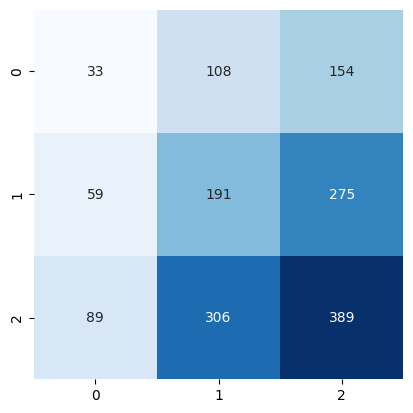

In [39]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the names of the ten classes
class_names = test_dataset.class_indices.keys()

def plot_heatmap(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
    )

plt.figure()
plot_heatmap(true_classes, pred_classes)    

plt.show()

# 